# ¿Qué es el Machine Learning?
El Machine Learning (Aprendizaje Automático) es una rama de la Inteligencia Artificial que se centra en desarrollar algoritmos que permiten a las máquinas aprender a partir de datos sin ser explícitamente programadas. Los algoritmos de ML identifican patrones en los datos y usan esos patrones para hacer predicciones o tomar decisiones.

## Aprendizaje Supervisado y No Supervisado
- **Aprendizaje Supervisado**: Modelo entrenado con datos etiquetados (regresión, clasificación).
- **Aprendizaje No Supervisado**: Modelo recibe datos sin etiquetas para encontrar patrones (clustering, reducción de dimensionalidad).

## Generación de Dataset Sintético
Generamos un dataset sintético para tareas de regresión y clasificación.

In [1]:
import pandas as pd
from sklearn.datasets import make_regression, make_classification
import numpy as np

X_reg, y_reg = make_regression(n_samples=500, n_features=5, noise=0.1, random_state=42)
df_reg = pd.DataFrame(X_reg, columns=[f"feat{i+1}" for i in range(5)])
df_reg['target_reg'] = y_reg

df_reg.head()

,feat1,feat2,feat3,feat4,feat5,target_reg
0,0.560919,-0.370011,-0.295480,-0.258796,1.598647,-23.254887
1,-1.024388,-0.926930,-0.252568,-0.059525,-3.241267,-152.683213
2,-2.650970,0.106430,1.091507,-0.254977,1.503993,-35.164529
3,-0.850520,-0.138456,-0.580523,-1.224298,-0.209023,-139.907009
4,-0.322680,-0.756795,-0.250833,-1.421811,1.501334,-159.624846


In [2]:
X_cls, y_cls = make_classification(n_samples=500, n_features=5, n_classes=2, n_informative=3, weights=[0.7, 0.3], random_state=42)
df_cls = pd.DataFrame(X_cls, columns=[f"feat{i+1}" for i in range(5)])
df_cls['target_cls'] = y_cls

df_cls.head()

,feat1,feat2,feat3,feat4,feat5,target_cls
0,0.280056,-1.126421,-0.772964,2.060626,-2.357044,0
1,-0.326002,0.343967,1.535987,-1.794578,1.293605,1
2,-0.802972,-1.112616,-1.088524,0.668720,-1.183952,0
3,0.012285,-0.350602,-1.359103,1.234112,-0.909008,0
4,0.043145,-1.077267,-0.873334,1.727960,-2.031498,0


## Práctico: Modelo Base de RandomForestRegressor
Entrenamos un RandomForestRegressor usando todos los datos de regresión.

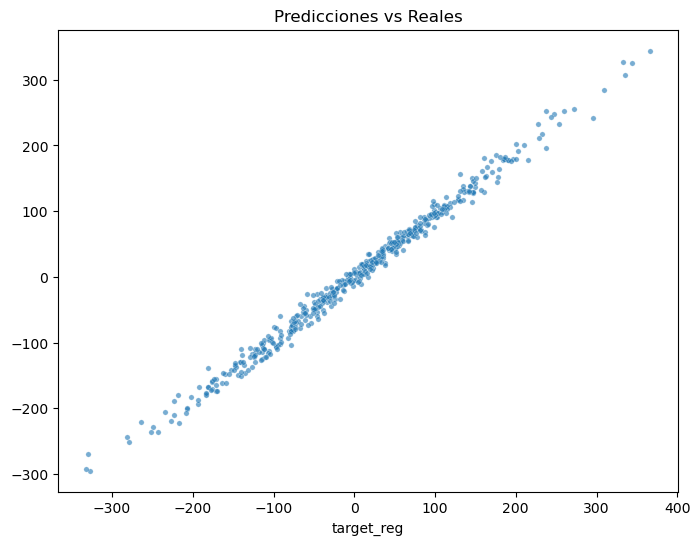

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

X = df_reg.drop('target_reg', axis=1)
y = df_reg['target_reg']

model = RandomForestRegressor(random_state=42)
model.fit(X, y)

preds = model.predict(X)
plt.figure(figsize=(8,6))
sns.scatterplot(x=y, y=preds, s=15, alpha=0.6)
plt.title('Predicciones vs Reales')
plt.show()

## Práctico: División de Datos
Dividimos los datos en entrenamiento y prueba.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
preds_test = model.predict(X_test)
print('R^2:', r2_score(y_test, preds_test))

R^2: 0.9284181158030568


## Práctico: EDA con Matriz de Correlación y Mapa de Calor

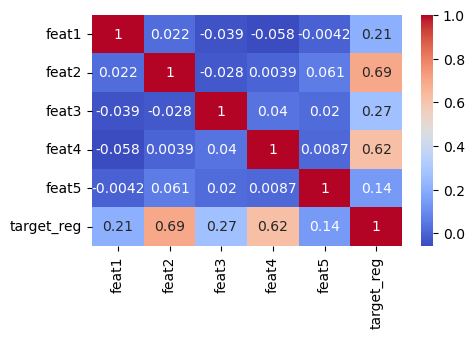

In [5]:
corr = df_reg.corr()
plt.figure(figsize=(5,3))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

## Práctico: Regresión Lineal

In [6]:
from sklearn.linear_model import LinearRegression
lin = LinearRegression()
lin.fit(X_train, y_train)
print('Coeficientes:', lin.coef_)
print('R^2 Lineal:', lin.score(X_test, y_test))

Coeficientes: [28.91715675 81.4161898  30.98124352 68.51541619 11.04216592]
R^2 Lineal: 0.9999991030723862


## Práctico: StandardScaler

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pd.DataFrame(X_scaled, columns=X.columns).describe().T

,count,mean,std,min,25%,50%,75%,max
feat1,500.0,0.000000e+00,1.001002,-2.791419,-0.686762,0.021660,0.677377,3.213883
feat2,500.0,1.776357e-17,1.001002,-2.840373,-0.645052,0.035175,0.642093,3.248756
feat3,500.0,4.529710e-17,1.001002,-3.113839,-0.667300,-0.048584,0.663252,3.769439
feat4,500.0,-3.907985e-17,1.001002,-2.828558,-0.653170,-0.019168,0.651382,2.469884
feat5,500.0,-7.105427e-18,1.001002,-3.441511,-0.704925,-0.016782,0.643862,3.280075


## Métricas de Regresión: MAE, MSE y R^2
- **MAE**: Error absoluto medio.
- **MSE**: Error cuadrático medio.
- **R^2**: Proporción de varianza explicada.

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
print('MAE:', mean_absolute_error(y_test, preds_test))
print('MSE:', mean_squared_error(y_test, preds_test))
print('R^2:', r2_score(y_test, preds_test))

MAE: 22.26638348727934
MSE: 848.5572027045713
R^2: 0.9284181158030568


## Práctico: Regresión Logística

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

Xc = df_cls.drop('target_cls', axis=1)
yc = df_cls['target_cls']
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)
log = LogisticRegression(max_iter=1000)
log.fit(Xc_train, yc_train)
yc_pred = log.predict(Xc_test)
print('Exactitud:', log.score(Xc_test, yc_test))

Exactitud: 0.88


## Métricas de Clasificación: Exactitud, Precisión, Recall y F1
- **Exactitud**: Proporción de predicciones correctas.
- **Precisión**: Verdaderos positivos / predicciones positivas.
- **Recall**: Verdaderos positivos / casos positivos reales.
- **F1-Score**: Media armónica entre precisión y recall.

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score
print('Precisión:', precision_score(yc_test, yc_pred))
print('Recall:', recall_score(yc_test, yc_pred))
print('F1:', f1_score(yc_test, yc_pred))

Precisión: 0.875
Recall: 0.7
F1: 0.7777777777777778


## Teórico: Curva ROC
La curva ROC muestra TPR vs FPR para diferentes umbrales. AUC mide capacidad de separación.

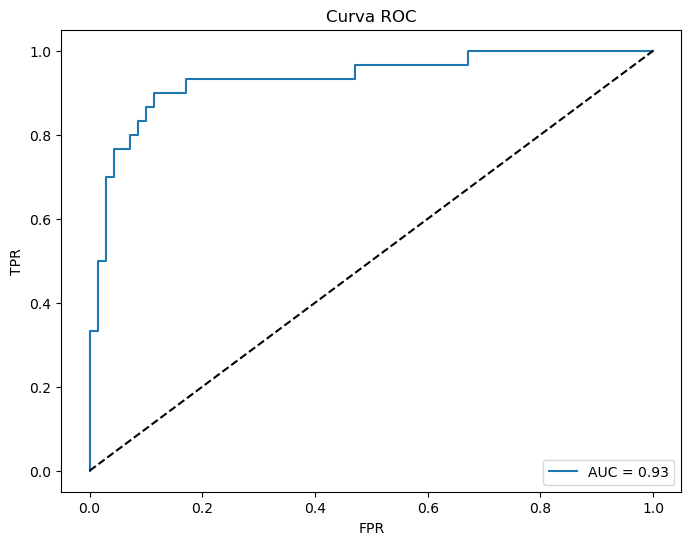

In [11]:
from sklearn.metrics import roc_curve, auc
y_score = log.predict_proba(Xc_test)[:, 1]
fpr, tpr, _ = roc_curve(yc_test, y_score)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6));
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}');
plt.plot([0,1],[0,1],'k--');
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('Curva ROC'); plt.legend(loc='lower right'); plt.show()

## Práctico: Balanceo de Clases

In [12]:
from sklearn.utils import resample
print('Distribución original:'); print(df_cls['target_cls'].value_counts())
df_major = df_cls[df_cls['target_cls']==0]
df_minor = df_cls[df_cls['target_cls']==1]
df_minor_up = resample(df_minor, replace=True, n_samples=df_major.shape[0], random_state=42)
df_bal = pd.concat([df_major, df_minor_up]); print('Balanced:'); print(df_bal['target_cls'].value_counts())

Distribución original:
target_cls
0    348
1    152
Name: count, dtype: int64
Balanced:
target_cls
0    348
1    348
Name: count, dtype: int64


## Práctico: Árboles de Decisión

In [13]:
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
dt_r = DecisionTreeRegressor(random_state=42); dt_r.fit(X_train, y_train)
print('R^2 DTree Reg:', dt_r.score(X_test, y_test))
dt_c = DecisionTreeClassifier(random_state=42); dt_c.fit(Xc_train, yc_train)
print('Exactitud DTree Cls:', dt_c.score(Xc_test, yc_test))

R^2 DTree Reg: 0.7987440301560951
Exactitud DTree Cls: 0.93


## Práctico: Random Forest (Regresión y Clasificación)

In [14]:
from sklearn.ensemble import RandomForestClassifier
rf_r = RandomForestRegressor(random_state=42); rf_r.fit(X_train, y_train)
print('R^2 RF Reg:', rf_r.score(X_test, y_test))
rf_c = RandomForestClassifier(random_state=42); rf_c.fit(Xc_train, yc_train)
print('Exactitud RF Cls:', rf_c.score(Xc_test, yc_test))

R^2 RF Reg: 0.9284181158030568
Exactitud RF Cls: 0.95


## Teórico: ¿Qué es el Clustering?
Clustering es un método de aprendizaje no supervisado que agrupa datos similares en clusters.

## Práctico: KMeans

c:\Users\ljpca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


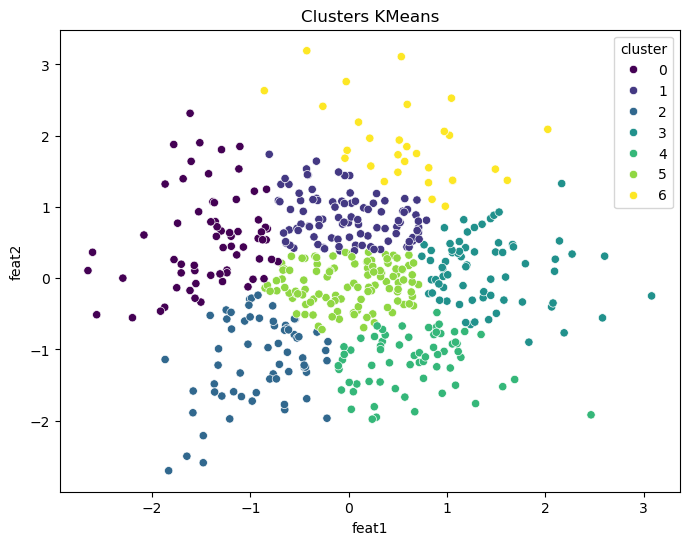

In [17]:
from sklearn.cluster import KMeans
X_clust = df_reg[['feat1','feat2']].values
km = KMeans(n_clusters=7, random_state=42); clusters = km.fit_predict(X_clust)
df_reg['cluster'] = clusters
plt.figure(figsize=(8,6)); sns.scatterplot(x='feat1', y='feat2', hue='cluster', palette='viridis', data=df_reg); plt.title('Clusters KMeans'); plt.show()